# **Concentration and Diversity in Collaboration Networks in Electrical Engineering: Evidence from Brazilian Researchers**

---

### **Authors**

- **Fernando A. do Carmo**  
  ORCID: https://orcid.org/0000-0003-4594-5924  

- **Gustavo S. Silva**  
  ORCID: https://orcid.org/0009-0001-1559-3465  

- **Raimundo C. S. Freire**  
  ORCID: https://orcid.org/0000-0002-5395-7143  

- **Antonio F. L. Jacob Jr**  
  ORCID: https://orcid.org/0000-0002-9415-7265  

- **Fábio M. F. Lobato**  
  ORCID: https://orcid.org/0000-0002-6282-0368  

---

<br>

#### **Notes on Supplementary Material**

This notebook contains the computational procedures, data analysis, and reproducibility materials associated with the article. All figures and tables generated here correspond to results discussed in the main manuscript.



In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
df_authors_path = None
df_authors = pd.read_csv(df_authors_path)

# Geographical analysis

In [38]:
!pip install -qU geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.2 MB/s eta 0:00:00


In [36]:
UF_TO_REGION = {
    # North
    "AC": "North", "AP": "North", "AM": "North", "PA": "North",
    "RO": "North", "RR": "North", "TO": "North",

    # Northeast
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast",
    "MA": "Northeast", "PB": "Northeast", "PE": "Northeast",
    "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",

    # Southeast
    "ES": "Southeast", "MG": "Southeast", "RJ": "Southeast", "SP": "Southeast",

    # South
    "PR": "South", "RS": "South", "SC": "South",

    # Midwest
    "DF": "Midwest", "GO": "Midwest", "MS": "Midwest", "MT": "Midwest",
}


In [37]:
df_authors = df_authors.assign(
    region=lambda d: d["uf"].map(UF_TO_REGION)
)

df_authors.region.value_counts()

,count
region,
Southeast,152
South,60
Northeast,53
Midwest,8
North,6


In [118]:
import geobr

from matplotlib import colors, patches

In [44]:
br_regions = geobr.read_region()
br_regions

,code_region,name_region,geometry
0,1.0,Norte,"MULTIPOLYGON (((-46.06095 -1.0947, -46.06666 -..."
1,2.0,Nordeste,"MULTIPOLYGON (((-38.65134 -17.94651, -38.65296..."
2,3.0,Sudeste,"MULTIPOLYGON (((-29.30279 -20.5158, -29.3054 -..."
3,4.0,Sul,"MULTIPOLYGON (((-48.46837 -27.70455, -48.46768..."
4,5.0,Centro Oeste,"MULTIPOLYGON (((-50.51107 -12.86077, -50.50895..."


In [45]:
br_regions = (
    br_regions
    .assign(
        name_region_en=lambda df: df.name_region.map({
            "Norte": "North",
            "Nordeste": "Northeast",
            "Sudeste": "Southeast",
            "Sul": "South",
            "Centro Oeste": "Midwest"
        }),
    )
    .assign(
        count=lambda df: df.name_region_en.map(
            df_authors.region.value_counts().to_dict()
        ),
        percentage=lambda df: 100 * df["count"] / df["count"].sum(),
        _region_count_label=lambda df: df.apply(
            lambda row: f"{row["percentage"]:.1f}%\n({row["count"]})",
            axis=1
        )
    )
)

In [46]:
region_colors = {
    "Midwest": "#ffffe5",
    "North": "#ffffe5",
    "Northeast": "#78c679",
    "South": "#78c679",
    "Southeast": "#379e54"
}

vmin, vmax = 0, 155
cmap = colors.ListedColormap(["#ffffe5", "#edf8b2", "#bce395", "#78c679", "#379e54"])

boundaries = [0, 10, 30, 55, 80, 155]
norm = colors.BoundaryNorm(boundaries, cmap.N)

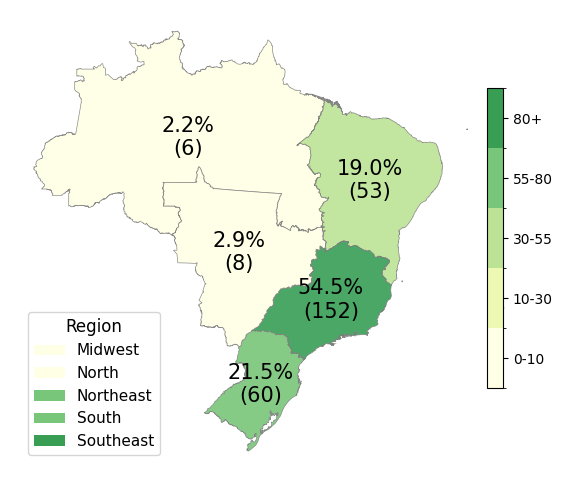

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

im = br_regions.plot(
    column="count", cmap=cmap, norm=norm, edgecolor="grey", linewidth=0.5,
    ax=ax, alpha=0.9, legend=False
)

br_regions.apply(
    lambda x: ax.annotate(
        text=x["_region_count_label"],
        xy=x.geometry.centroid.coords[0],
        ha="center", va="center", size=15,
        color="black",
    ),
    axis=1
)

ax.set_axis_off()
cbar_ax = fig.add_axes([0.85, 0.25, 0.02, 0.5])

cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax, boundaries=boundaries,
    ticks=[5, 20, 42.5, 67.5, 117.5],
    spacing="uniform", shrink=0.4,
)

cbar.ax.set_yticklabels(["0-10", "10-30", "30-55", "55-80", "80+"], fontsize=10)

legend_elements = [
    patches.Patch(facecolor=color, label=region)
    for region, color in region_colors.items()
]

legend = ax.legend(
    handles=legend_elements,
    title="Region", loc="lower left", fontsize=11, title_fontsize=12,
    frameon=True, fancybox=True, bbox_to_anchor=(0.02, 0.02)
)

plt.subplots_adjust(right=1.03)

# Gender analysis

In [ ]:
import requests

In [ ]:
IBGE_API_URL = "http://servicodados.ibge.gov.br/api/v1/censos/nomes/basica"

In [ ]:
from unicodedata import normalize

# João -> JOAO
def encode(name: str) -> str:
    ascii_name = normalize("NFKD", name).encode("ascii", errors="ignore").decode("ascii")
    return ascii_name.upper()

In [ ]:
from functools import lru_cache

@lru_cache(maxsize=1024)
def get_gender_by_name(name: str) -> str:
    name = encode(name)

    if not name:
        return "I"

    def query(sex: str):
        response = requests.get(
            IBGE_API_URL,
            params={"nome": name, "sexo": sex},
            timeout=5,
        )
        response.raise_for_status()
        data = response.json()
        return data[0]["rank"] if data else None

    try:
        rank_f = query("f")
        rank_m = query("m")

    except requests.RequestException:
        print(f"bad request: {name=}")
        return "I"

    if rank_f is None and rank_m is None:
        return "I"

    if rank_f is None:
        return "M"

    if rank_m is None:
        return "F"

    return "F" if rank_f < rank_m else "M"

In [ ]:
df = (
    df_authors[["nome"]]
    .assign(primeiro_nome=lambda df: df.nome.str.split(" ").str[0].apply(encode))
)

In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()

In [ ]:
df_sex = (
    df
    .assign(
        sexo=lambda df: df.primeiro_nome.progress_apply(get_gender_by_name)
    )
)

  0%|          | 0/419 [00:00<?, ?it/s]

In [ ]:
df_sex.sexo.value_counts()

,count
sexo,
M,372
F,34
I,13


In [ ]:
df_authors = (
    df_authors
    .merge(df_sex, how="left", on="nome")
    .rename(columns={"Unnamed: 0": "index"})
    .set_index("index")
)

In [ ]:
df_gender_analysis = (
    df_authors
    .dropna(subset=["sexo", "region", "uf"])
    .query("sexo in ['M', 'F']")
)

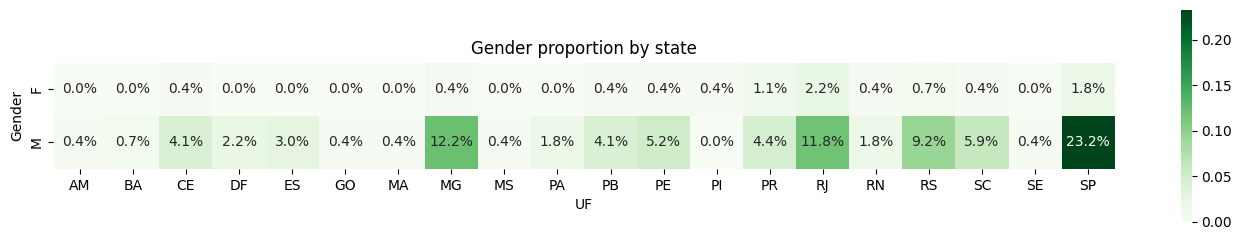

In [80]:
import seaborn as sns

heatmap_data = (
    df_gender_analysis
    .value_counts(["uf", "sexo"], normalize=True)
    .rename("proportion")
    .reset_index()
    .pivot(index="uf", columns="sexo", values="proportion")
    .fillna(0.0)
)

plt.figure(figsize=(14, 2.5))
sns.heatmap(
    heatmap_data.T, annot=True, fmt=".1%",
    cmap="Greens", square=1
)

plt.title("Gender proportion by state")
plt.xlabel("UF")
plt.ylabel("Gender")
plt.tight_layout()
plt.show()

In [126]:
female_ratio_by_region = (
    df_gender_analysis
    .groupby("region")["sexo"]
    .apply(lambda x: (x == "F").mean() * 100)
    .to_dict()
)

female_count_by_region = (
    df_gender_analysis
    .groupby("region")["sexo"]
    .apply(lambda x: (x == "F").sum())
    .to_dict()
)

br_regions = (
    br_regions
    .assign(
        name_region_en=lambda df: df.name_region.map({
            "Norte": "North",
            "Nordeste": "Northeast",
            "Sudeste": "Southeast",
            "Sul": "South",
            "Centro Oeste": "Midwest"
        }),
    )
    .assign(
        pct_female=lambda df: df.name_region_en.map(female_ratio_by_region),
        count_female=lambda df: df.name_region_en.map(female_count_by_region),
        _region_label=lambda df: df.apply(
            lambda row: f"{row['pct_female']:.1f}%\n({int(row['count_female'])})",
            axis=1
        )
    )
)

In [135]:
region_colors = {
    "North": "#d4e6f1",
    "Midwest": "#d4e6f1",
    "Southeast": "#e8daef",
    "Northeast": "#d7bde2",
    "South": "#c39bd3"
}

vmin, vmax = 0, 12
cmap = colors.ListedColormap(["#d4e6f1", "#e8f4f8", "#f5eef8", "#e8daef", "#d7bde2", "#c39bd3"])

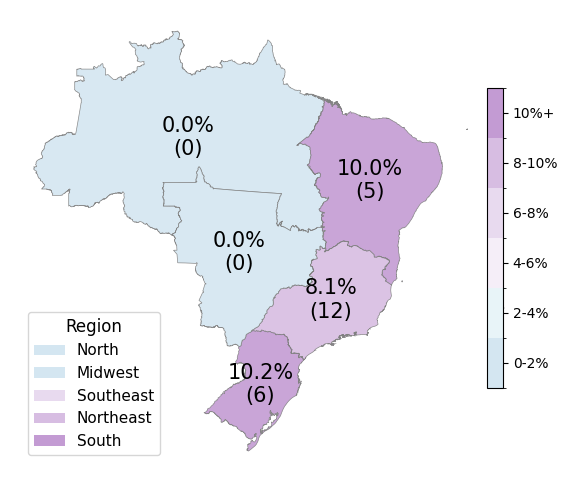

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

im = br_regions.plot(
    column="pct_female", cmap=cmap, norm=norm, edgecolor="grey", linewidth=0.5,
    ax=ax, alpha=0.9, legend=False
)

br_regions.apply(
    lambda x: ax.annotate(
        text=x["_region_label"],
        xy=x.geometry.centroid.coords[0],
        ha="center", va="center", size=15,
        color="black",
    ),
    axis=1
)

ax.set_axis_off()
cbar_ax = fig.add_axes([0.85, 0.25, 0.02, 0.5])

cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax, boundaries=boundaries,
    ticks=[1, 3, 5, 7, 9, 11],
    spacing="uniform", shrink=0.4,
)

cbar.ax.set_yticklabels(["0-2%", "2-4%", "4-6%", "6-8%", "8-10%", "10%+"], fontsize=10)

legend_elements = [
    patches.Patch(facecolor=color, label=region)
    for region, color in region_colors.items()
]

legend = ax.legend(
    handles=legend_elements,
    title="Region", loc="lower left", fontsize=11, title_fontsize=12,
    frameon=True, fancybox=True, bbox_to_anchor=(0.02, 0.02)
)

plt.subplots_adjust(right=1.03)
plt.show()